# Regression Model Eval


## Librerías

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle
from warnings import filterwarnings

filterwarnings('ignore')


In [56]:
sns.set_style("white") 
sns.set_palette("pastel")
plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.figsize": (8, 4),
    "axes.edgecolor": "0.8",
})

## Load data

In [57]:
df = pd.read_parquet("../data/processed/feature_dataset.parquet")
df.head()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,season,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real,movement_pattern
0,1,1986-07-01 18:00:00,69.7730,-141.3960,5835,5835,69.772693,-141.403451,NaN,NaN,...,verano,-2.199487e+06,246846.113968,NaN,NaN,NaN,NaN,0.000000,1.560623,estacionario
1,1,1986-07-02 00:00:00,69.7738,-141.3834,2517,2517,69.773429,-141.388987,69.772693,-141.403451,...,verano,-2.199467e+06,246281.720783,5835.0,5835.0,154.841241,NaN,0.000000,7.640792,estacionario
2,1,1986-07-02 06:00:00,69.7736,-141.3448,5323,5323,69.764930,-141.331186,69.773429,-141.388987,...,verano,-2.200658e+06,244167.346190,2517.0,2517.0,148.477694,154.841241,6.363548,7.640792,estacionario
3,1,1986-07-02 12:00:00,69.7727,-141.2902,8840,8840,69.783728,-141.265125,69.764930,-141.331186,...,verano,-2.198852e+06,241400.844917,5323.0,5323.0,176.425859,148.477694,27.948165,7.640792,estacionario
4,1,1986-07-02 18:00:00,69.7717,-141.2289,11637,11637,69.778055,-141.296034,69.783728,-141.265125,...,verano,-2.199351e+06,242656.504996,8840.0,8840.0,157.258475,176.425859,19.167384,7.640792,estacionario


In [58]:
df.TotalDistance_km

0         2261.865676
1         2261.865676
2         2261.865676
3         2261.865676
4         2261.865676
             ...     
294210    5599.996123
294211    5599.996123
294212    5599.996123
294213    5599.996123
294214    5599.996123
Name: TotalDistance_km, Length: 294215, dtype: float64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294215 entries, 0 to 294214
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   UniqueAnimalID         294215 non-null  int64         
 1   timestamp              294215 non-null  datetime64[ns]
 2   mu_lat                 294215 non-null  float64       
 3   mu_lon                 294215 non-null  float64       
 4   se_mu_x                294215 non-null  int64         
 5   se_mu_y                294215 non-null  int64         
 6   adj_lat                294215 non-null  float64       
 7   adj_lon                294215 non-null  float64       
 8   prev_lat               293822 non-null  float64       
 9   prev_lon               293822 non-null  float64       
 10  prev_time              294215 non-null  datetime64[ns]
 11  distance_km            294215 non-null  float64       
 12  time_diff_hr           294215 non-null  floa

In [5]:
df.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294215 entries, 0 to 294214
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   date              294215 non-null  object
 1   season            294215 non-null  object
 2   movement_pattern  294215 non-null  object
dtypes: object(3)
memory usage: 6.7+ MB


In [10]:
df.isna().sum()

UniqueAnimalID             0
timestamp                  0
mu_lat                     0
mu_lon                     0
se_mu_x                    0
se_mu_y                    0
adj_lat                    0
adj_lon                    0
prev_lat                 393
prev_lon                 393
prev_time                  0
distance_km                0
time_diff_hr               0
velocity_kmh               0
prev_velocity              0
acceleration_kmph2         0
date                       0
daylight_hours             0
is_polar_night             0
is_midnight_sun            0
min                        0
max                        0
dias_tracking              0
TotalDistance_km           0
distance_per_day           0
AvgLatitude                0
AvgLongitude               0
Year                       0
season                     0
x_proj                     0
y_proj                     0
prev_se_x                393
prev_se_y                393
bearing                  393
prev_bearing  

In [35]:
df.season.unique()

array(['verano', 'transicion', 'invierno'], dtype=object)

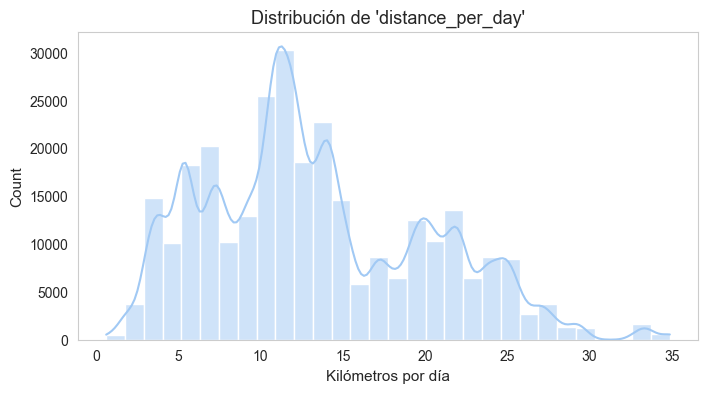

In [6]:
# 03 - Visualización del target
sns.histplot(df["distance_per_day"], kde=True, bins=30)
plt.title("Distribución de 'distance_per_day'")
plt.xlabel("Kilómetros por día")
plt.show()


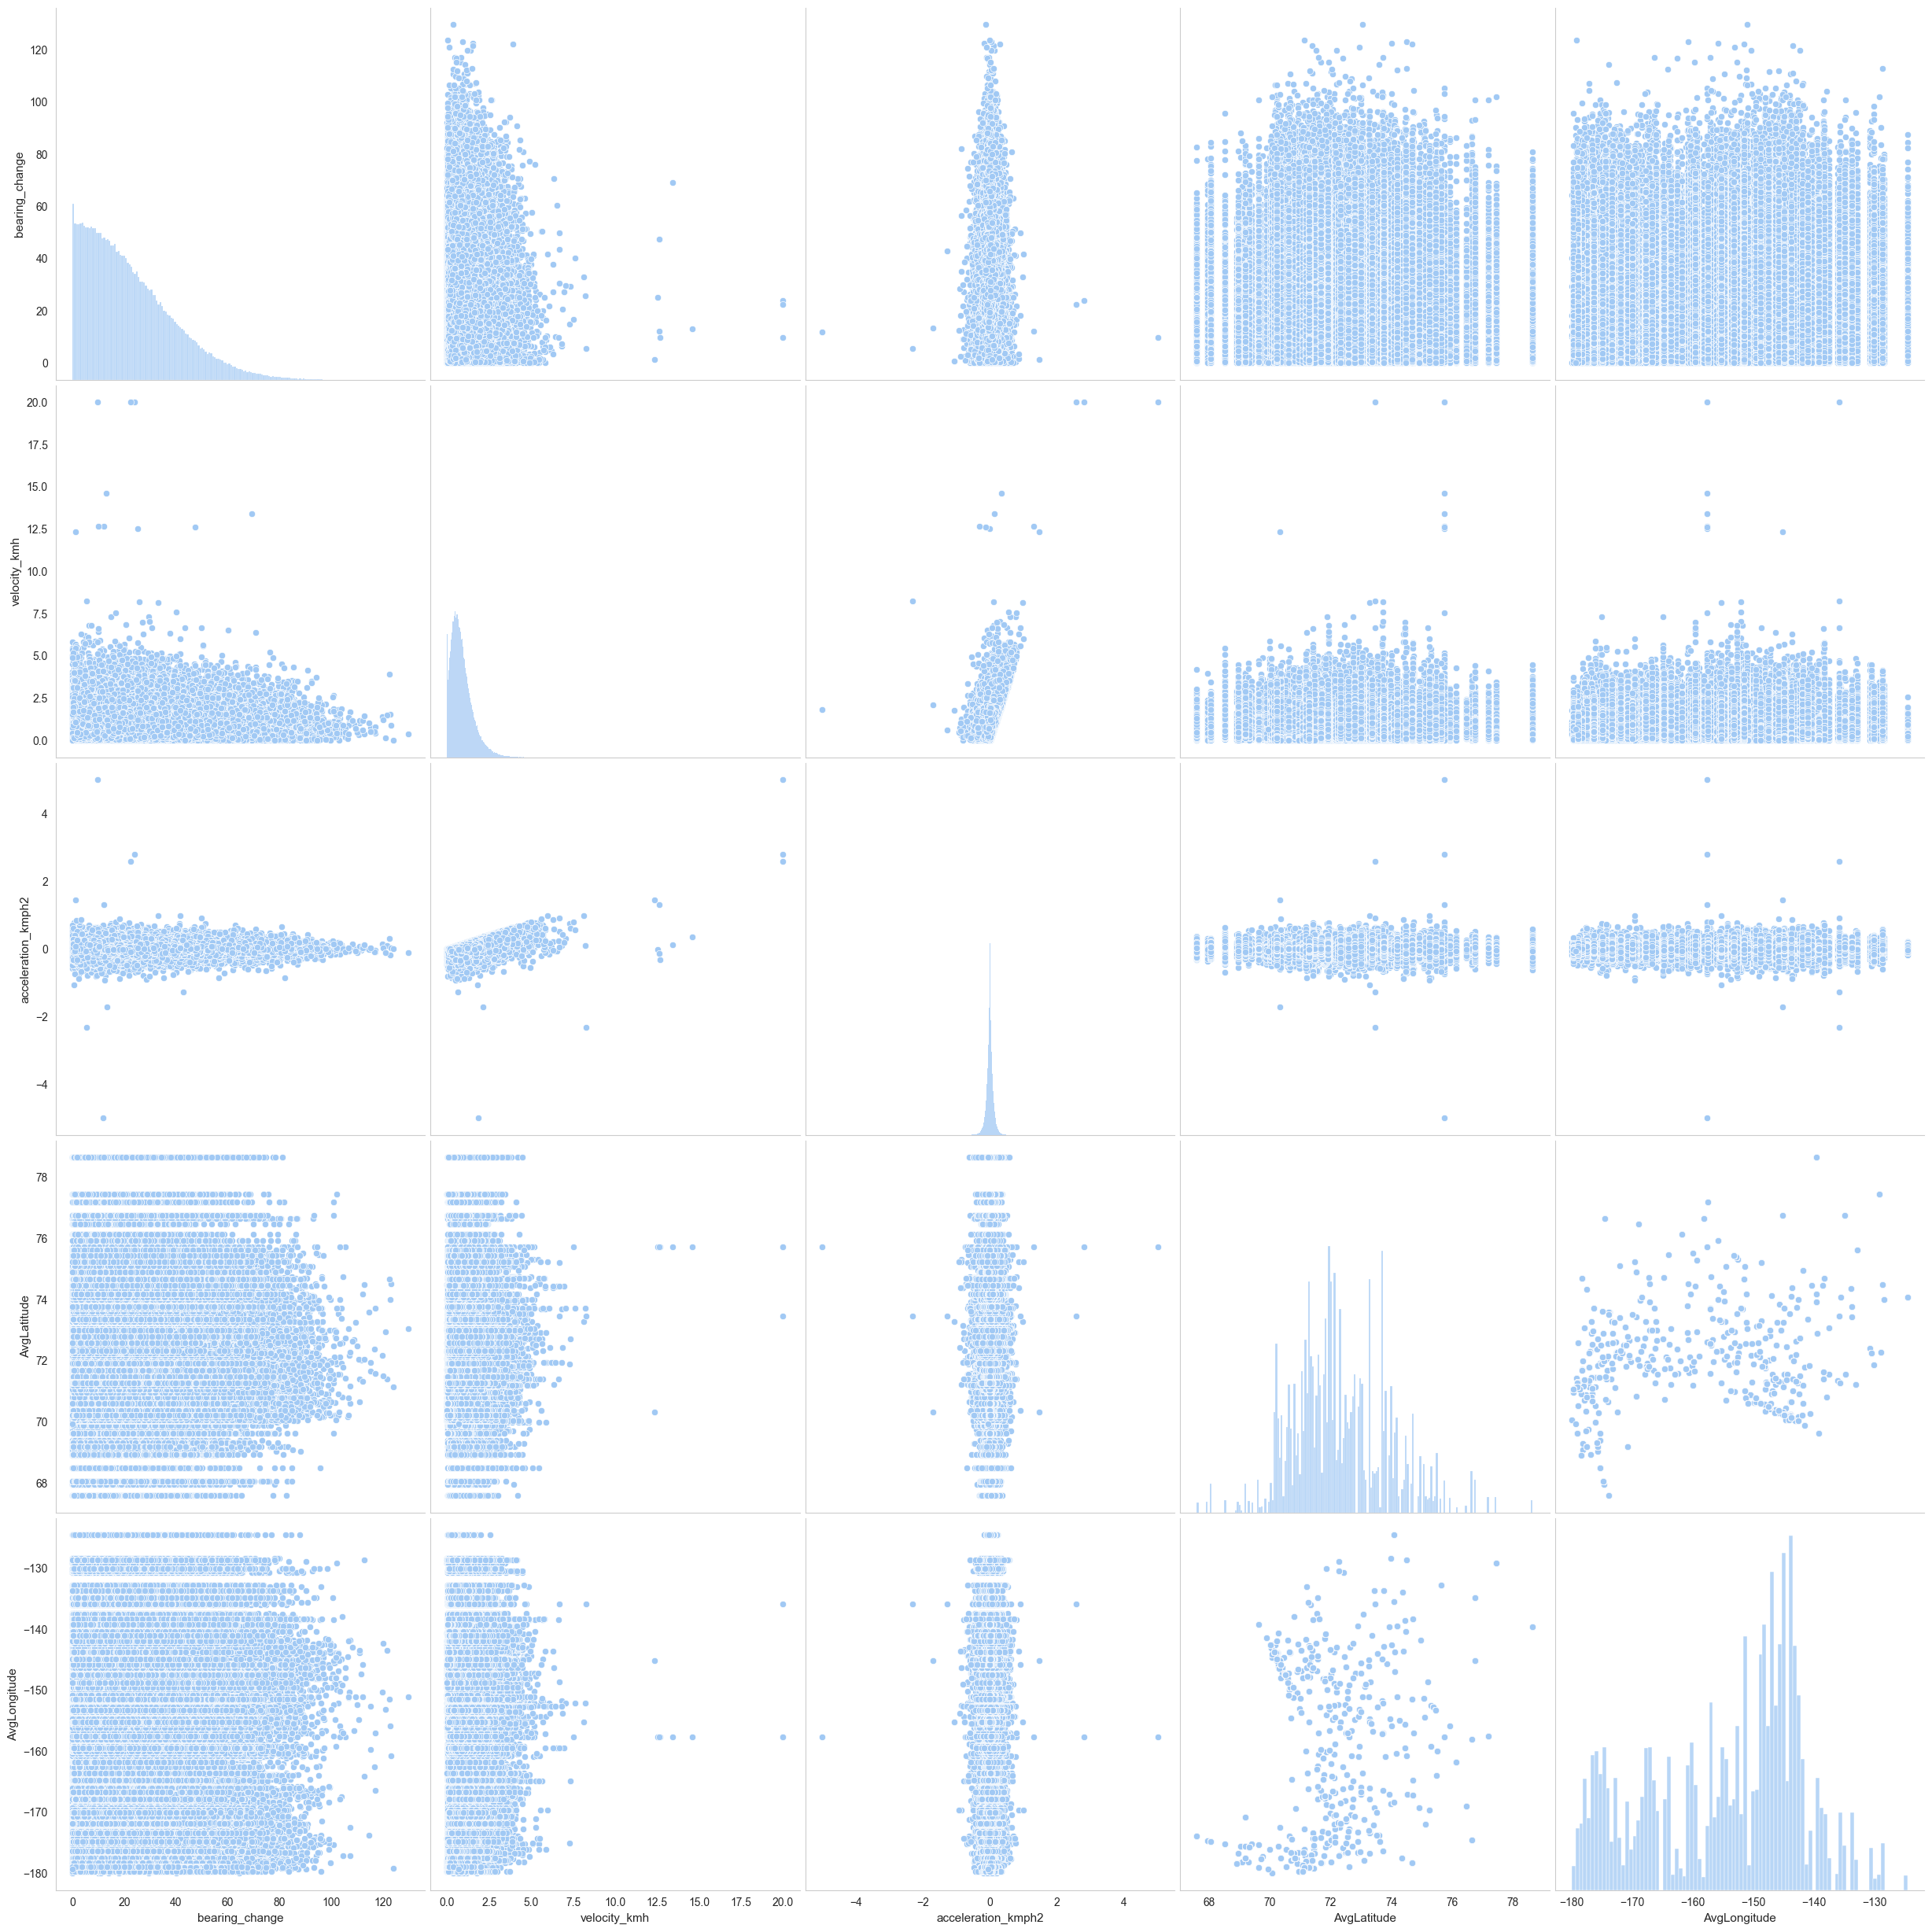

In [21]:
sns.pairplot(df[["bearing_change", "velocity_kmh", "acceleration_kmph2", "AvgLatitude", "AvgLongitude"]], diag_kind='hist', palette='bright', height=5, aspect=1)

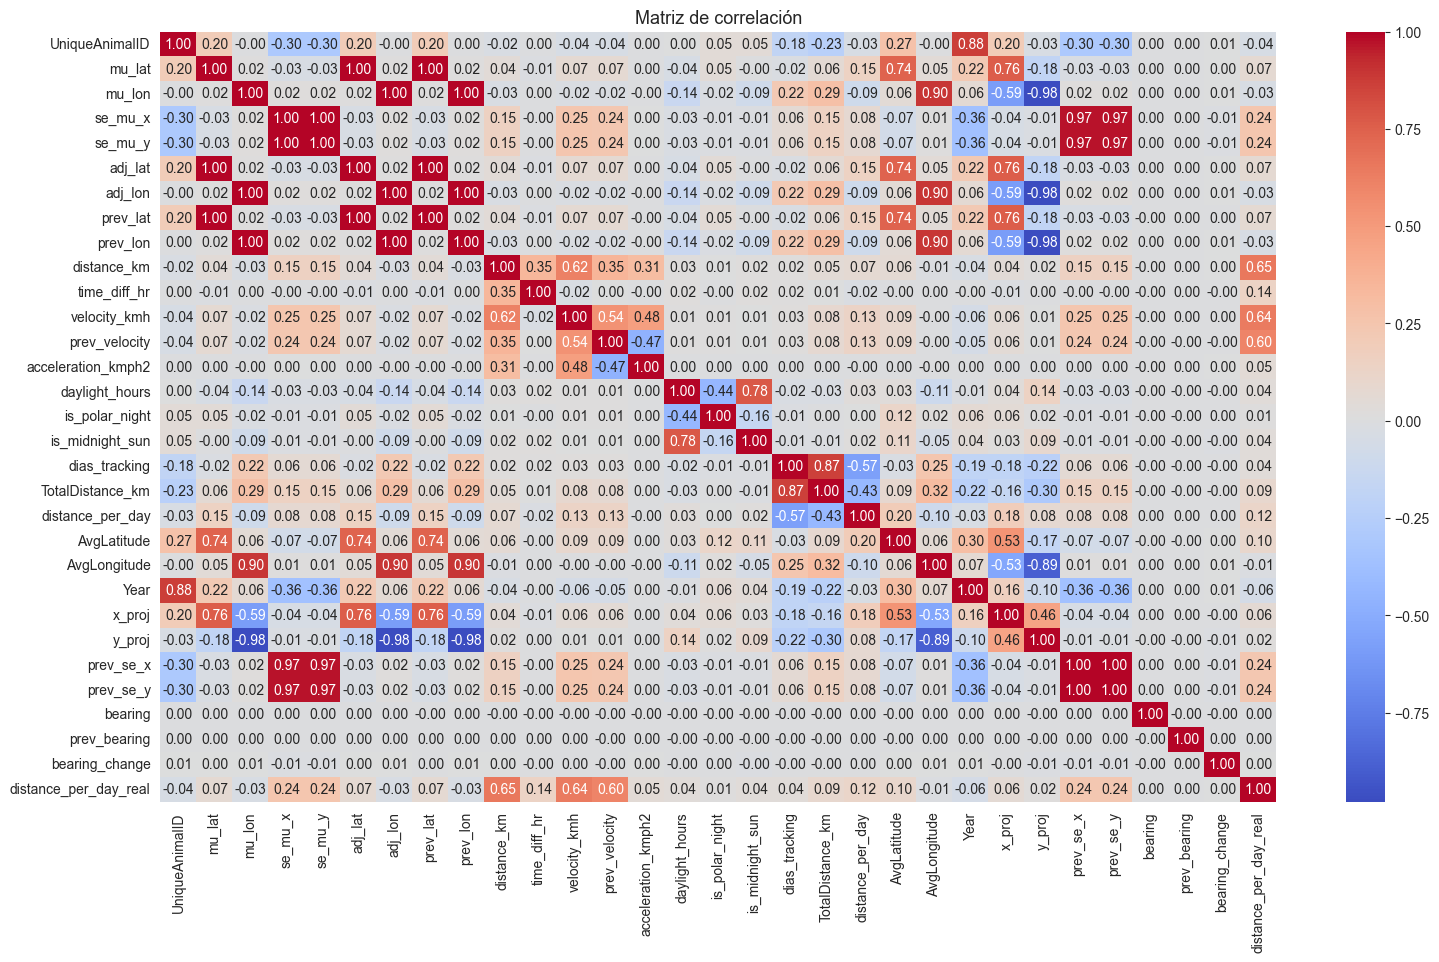

In [18]:
# 04 - Heatmap de correlaciones
plt.figure(figsize=(18, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()


In [45]:
# Codificación de variables categóricas
df = pd.get_dummies(df, columns=["season", "movement_pattern"], drop_first=True)
df.columns


# - Selección vars
target = "distance_per_day"
features = ['TotalDistance_km', 'AvgLatitude', 'AvgLongitude']

df = df[[target] + features].dropna()

X = df[features]
y = df[target]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(205950, 3)
(88265, 3)
(205950,)
(88265,)


In [46]:
df.distance_per_day.describe()

count    294215.000000
mean         13.358301
std           6.725782
min           0.627025
25%           8.336381
50%          12.074120
75%          18.370834
max          34.889125
Name: distance_per_day, dtype: float64

In [47]:
# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)


In [48]:
# Modelos
models = {
    "Linear (no scaled)": LinearRegression().fit(X_train, y_train),
    "Linear (scaled)": LinearRegression().fit(X_train_scaled, y_train),
    "RidgeCV (scaled)": RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(X_train_scaled, y_train),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=10)
}

# Evaluación
def evaluar_modelo(nombre, modelo, Xtr, Xte):
    pred_train = modelo.predict(Xtr)
    pred_test = modelo.predict(Xte)
    return {
        "Modelo": nombre,
        "MAE train": mean_absolute_error(y_train, pred_train),
        "MAE test": mean_absolute_error(y_test, pred_test),
        "RMSE train": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSE test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "R² train": r2_score(y_train, pred_train),
        "R² test": r2_score(y_test, pred_test)
    }

resultados = []
for nombre, modelo in models.items():
    if "scaled" in nombre:
        res = evaluar_modelo(nombre, modelo, X_train_scaled, X_test_scaled)
    elif nombre == "Random Forest":
        modelo.fit(X_train, y_train)
        res = evaluar_modelo(nombre, modelo, X_train, X_test)        
    else:
        res = evaluar_modelo(nombre, modelo, X_train, X_test)
    resultados.append(res)

# Comparar resultados
df_resultados = pd.DataFrame(resultados).sort_values("R² test", ascending=False)
print(df_resultados)


               Modelo     MAE train   MAE test    RMSE train  RMSE test  \
3       Random Forest  5.075010e-14   0.000066  6.714344e-14   0.019713   
1     Linear (scaled)  4.688754e+00   4.674624  5.872545e+00   5.860583   
2    RidgeCV (scaled)  4.688747e+00   4.674617  5.872545e+00   5.860583   
0  Linear (no scaled)  6.892892e+01  68.945900  6.924422e+01  69.261025   

     R² train     R² test  
3    1.000000    0.999991  
1    0.237690    0.240567  
2    0.237690    0.240567  
0 -104.985335 -105.068264  


In [54]:
#  Guardar mejor modelo
mejor_nombre = df_resultados.iloc[0]["Modelo"]
mejor_modelo = models[mejor_nombre]

with open("../models/mejor_modelo_regresion.pkl", "wb") as f:
    pickle.dump(mejor_modelo, f)

print(f"Modelo guardado: {mejor_nombre}")


Modelo guardado: Random Forest


I. Prueba con todas las columns. Resultado:  
features = df.select_dtypes(include=[np.number]).drop(columns=[target, "UniqueAnimalID"]).columns.tolist() # RF Overfitting  

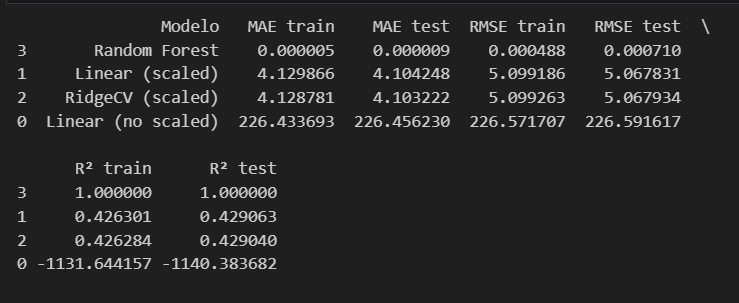

II. Prueba

- features = [
    "bearing_change", "velocity_kmh", "acceleration_kmph2",
    "daylight_hours", "is_polar_night", "is_midnight_sun",
    "AvgLatitude", "AvgLongitude", "TotalDistance_km", 
    'season_transicion', 'season_verano', 'movement_pattern_estacionario'
]

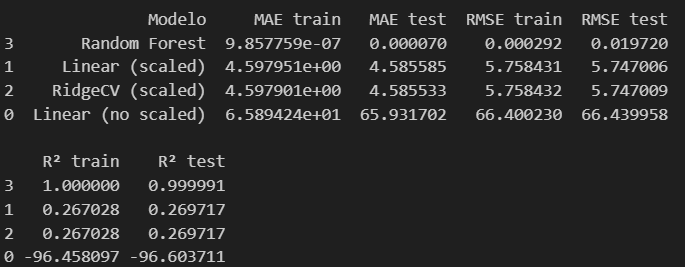  

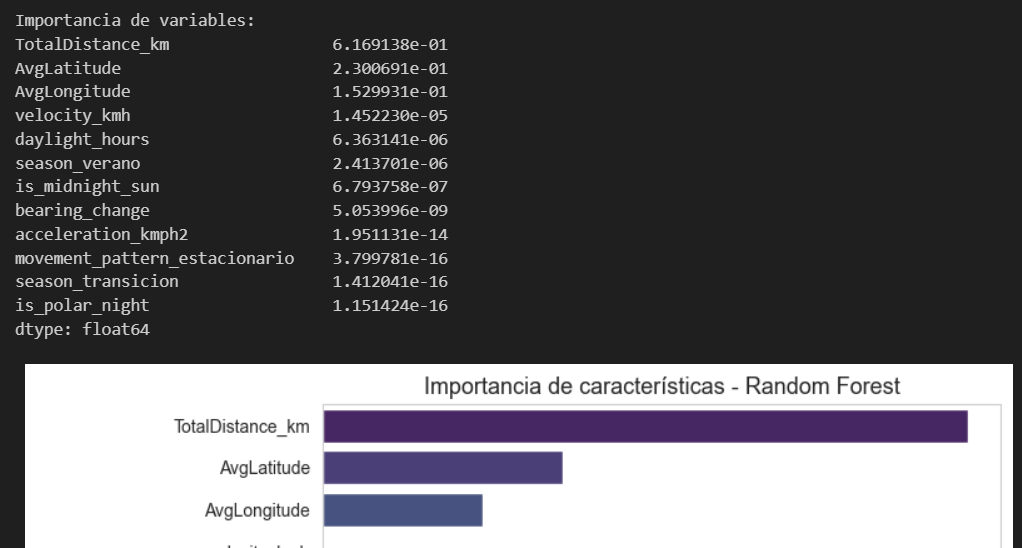

III. Prueba 

features = ['TotalDistance_km', 'AvgLatitude', 'AvgLongitude']

Explicar el modelo más fácilmente a stakeholders: "el patrón diario de movimiento depende casi exclusivamente de dónde está el animal y cuánto se ha movido en total".

Importancia de variables:
TotalDistance_km                 6.169138e-01
AvgLatitude                      2.300691e-01
AvgLongitude                     1.529931e-01
velocity_kmh                     1.452230e-05
daylight_hours                   6.363141e-06
season_verano                    2.413701e-06
is_midnight_sun                  6.793758e-07
bearing_change                   5.053996e-09
acceleration_kmph2               1.951131e-14
movement_pattern_estacionario    3.799781e-16
season_transicion                1.412041e-16
is_polar_night                   1.151424e-16
dtype: float64


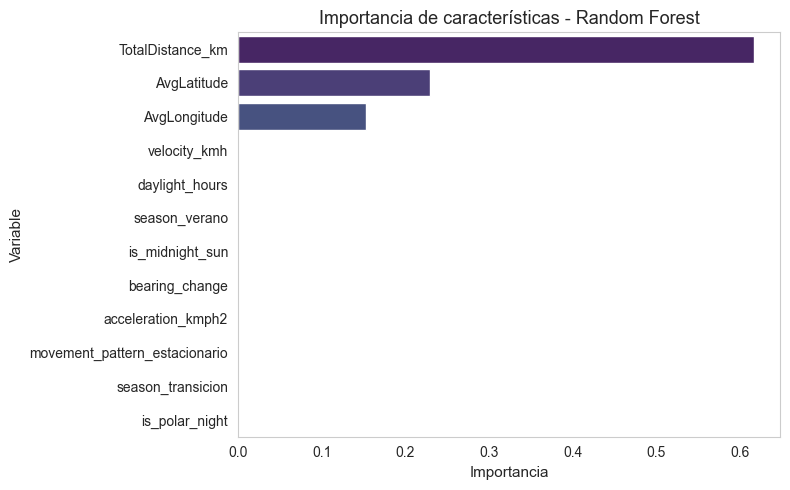

In [42]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=10)
model_rf.fit(X_train, y_train)

# Extraer importancias
importancias = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

# Imprimir
print("Importancia de variables:")
print(importancias)

# Visualizar
plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, palette="viridis")
plt.title("Importancia de características - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


IV. Prueba 

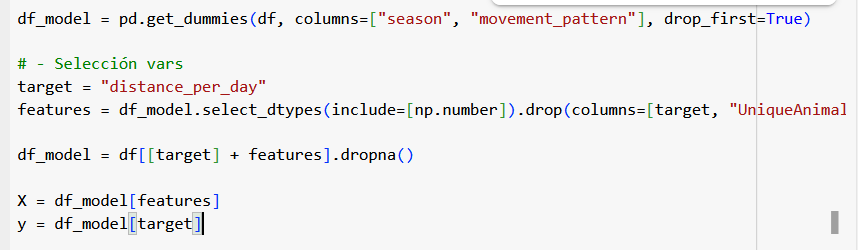  

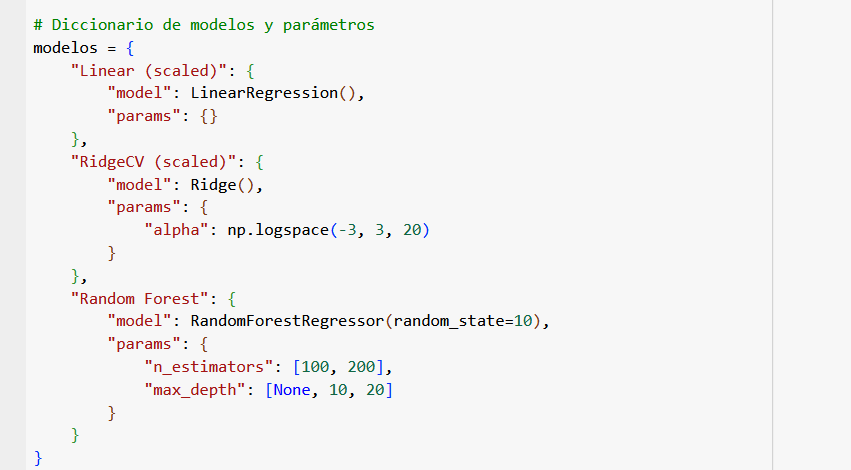

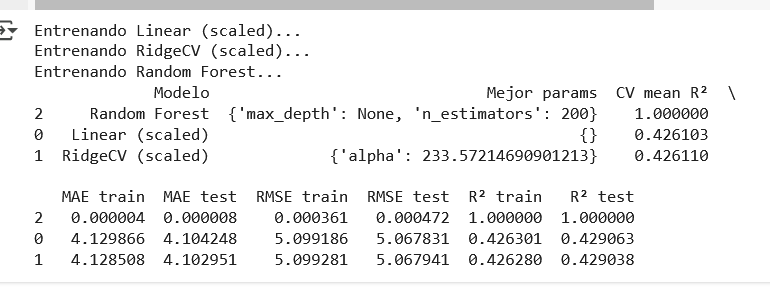

